# Exploratory Data Analysis (EDA) and Data Visualizations

## Introduction

In the most recent lecture, you've learned about the fundamental techniques used by data scientists when exploring real-world data (collectively known as Exploratory Data Analysis, or EDA). A core part of this process is data visualizations, an incredibly useful approach in initially understanding the data, showing underlying trends or distributions, and communicating relevant results to non-technical audiences.

Here, you will get to have a little more hands-on practice with these skills. We will be operating on a small dataset today using libraries such as Python Pandas, Matplotlib, and Seaborn! Run the two cells below to import those libraries and set up the notebook.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = {
    "name": ["CR7", "Messi", "Neymar", "Muller", "Neuer", "Kimmich", "Musiala", "Olise", "Palmer", "Salah", "Bruno Fernandes", "Sameer", "Nathan", "Bo"],
    "career_goals": [965, 890, 450, 300, 0, 60,  60,  70, 85, 390, 240,  82,  75,   2],
    "league": ["Saudi Pro League", "MLS", "Brasileirao", "MLS", "Bundesliga", "Bundesliga", "Bundesliga", "Bundesliga", "Premier League", "Premier League", "Premier League", "Berkeley Super League", "Berkeley Super League", "Berkeley Super League"],
    "age": [41, 38, 33, 36, 39, 31, 22, 24, 23, 33, 31, 19, 19, 19],
    "went_to_berkeley": [False, False, False, False, False, False, False, False, False, False, False, True, True, True]
}

df = pd.DataFrame(data)
df

,name,career_goals,league,age,went_to_berkeley
0,CR7,965,Saudi Pro League,41,False
1,Messi,890,MLS,38,False
2,Neymar,450,Brasileirao,33,False
3,Muller,300,MLS,36,False
4,Neuer,0,Bundesliga,39,False
5,Kimmich,60,Bundesliga,31,False
6,Musiala,60,Bundesliga,22,False
7,Olise,70,Bundesliga,24,False
8,Palmer,85,Premier League,23,False
9,Salah,390,Premier League,33,False


# Part 1: Beginner (Required)

There are many, many types of visualizations out there, but we will be covering some very basic ones right now. Take a look at this dataset? What are some trends you might want to uncover? What are some things that you want to see in the form of graphs and pictures?

### Q1: Bar Graph

Say, for instance, we're interested in seeing the league distribution among these soccer players (who plays in which league currently). We could then consider using a **bar graph** to show the differences between each group and compare them side by side using your chosen metric or *categorical* variable! Run the cell below to find out what this looks like.

<Axes: xlabel='count', ylabel='league'>

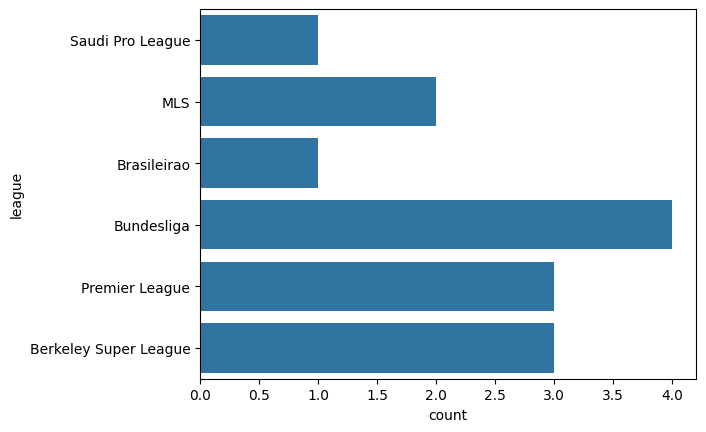

In [ ]:
sns.countplot(df["league"])

This then immediately shows us that more players in the dataset play in the Bundesliga than any other league!

**Written Question**: The bar plot is a simple yet extremely powerful tool used by data scientists to identify differences between categorical/discrete data. However, using it on a quantitative or continuous variable may not always be the move. Can you think of why that is? Feel free to try to call sns.countplot() on quantitative variables instead!

> *Your answer here:*

### Q2: Histograms, KDEs, and the Mysterious Plot

Another common graph used in EDA is the **histogram**, often confused with the bar plot mentioned above due to their obvious similarities visually. However, instead of being used to compare categorical variable distributions, a histogram is used to visualize the distribution of a single numerical variable grouped into bins. This helps us easily visualize the shape of a distribution and determine whether it's normal, skewed, uniform, or something else entirely.

Let's get back to our soccer player dataset. Say, we want to visualize the general distribution of the goals scored by each player in the dataset. Run the cell below to find out!

<Axes: xlabel='career_goals', ylabel='Count'>

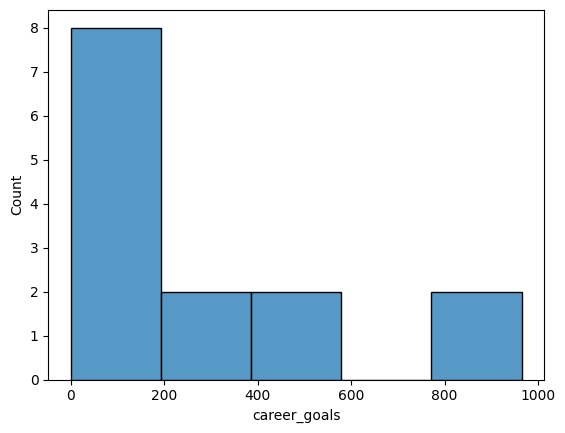

In [ ]:
sns.histplot(df["career_goals"])

Wow! That is a really interesting distribution. Based on your knowledge of statistics and what you see in this plot, what are two adjectives you can use to describe the distribution?

> *Your answer here:*

A very closely related graph is known as a **Kernel Density Distribution** (KDE). A KDE draws a smooth continuous curve over the same data, representing a single, flowy line instead of bins. Run the cell below and adjust its parameters (try tweaking the values of *bw_adjust*!) to find out what changes it can make!

<Axes: xlabel='career_goals', ylabel='Density'>

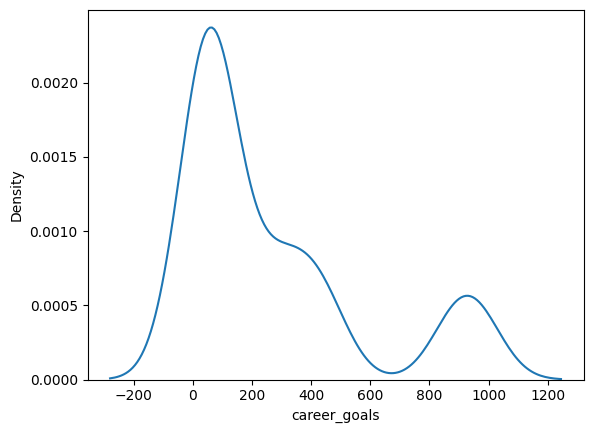

In [ ]:
sns.kdeplot(data=df, x="career_goals", bw_adjust=0.5)

**Written Question**: What did you notice when you tested different values for bw_adjust inside the function? What do you think this parameter represents?

> *Your answer here:*

Unfortunately, because the histogram by definition is used to group input values into various intervals (and then measuring their frequencies), it does not provide us enough insights into what those specific values are. For instance, just by looking at the graph above, you have no way of knowing if the 2 people in the top bin [800, 1000) scored 800 or 999 goals (without referencing the original dataframe directly, that is).  

Luckily, we learned another type of graph in lecture that might be slightly better in achieving our goals! It is used when when we want to visualize a single numerical variable's distribution, along with important summary statistics and outliers.

**Based on your lecture notes, use Matplotlib or Seaborn to make a graph that not only visualizes the number of goals scored by each player but also any potential outliers that might be present in our distribution. Your final graph should resemble the picture shown below.**

![Reference_Photo](https://i.imgur.com/n3848h4.png)

### Q3: Scatterplot

Now we want to go one step further to not just look at one single distribution but rather how two variables in the dataset relate to one another.

**Say that we want to see whether there is any visible relationship between the players' ages and the number of goals they've scored professionally so far. A natural instinct in this situation would be to use a ________**:

A: Line Graph  

B: Pie Chart  

C: Scatterplot  

D: Histogram

If your answer to the last question was the third letter in the alphabet, then congrats, you are right! Scatterplot is a fantastic way to visualize the relationship between 2 numerical variables, where each dot on the graph represents one observation and the line passing through the points representing the line of best fit determined by our algorithm. Run the cell below to find out what this looks like.

<Axes: xlabel='age', ylabel='career_goals'>

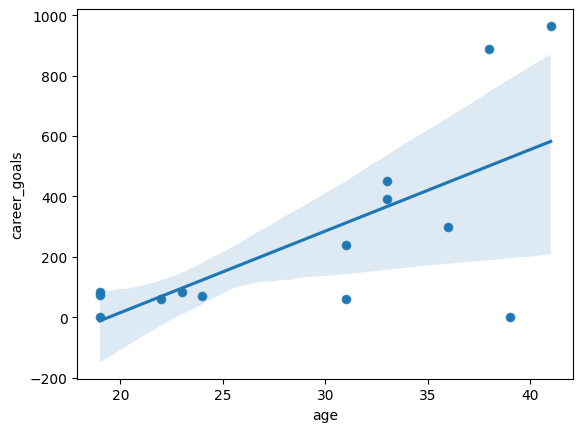

In [ ]:
sns.scatterplot(data=df, x="age", y="career_goals")
sns.regplot(data=df, x="age", y="career_goals")

Even though our dataset does not have a lot of data points, we can still see a moderate, positive correlation between the x and y variables. That is, increases in a player's age is directly associated with increases in the number of goals throughout career. This is a very plausible conclusion: a player who has played for more than two decades would likely have accumulated more goals than someone who just started playing soccer professionally.

Just by looking at the points, however, it's also easy to spot a couple of outliers as well. For instance, Neuer (at the age of 39) has never scored a single competitive goal in his career, a sign that he might not be the most efficient player.

**Written Question**: Talk about 2 other interesting observations you're able to make from this scatterplot and the line of best fit.

> *Your answer here:*

## Part 2: Advanced (Optional)

Now, instead of pure, one-by-one visualizations, we will attempt to answer a real data science question in the dataset motivated by basic data manipulation and data visualizations learned in lecture.

### Q1: Are Berkeley youngsters GOATED?

In this question, you will independently write code to determine **if the typical player from Berkeley is more efficient than the other non-Berkeley players playing in the world's most famous leagues, including the likes of Cristiano Ronaldo, Messi, Neymar, etc**.

We can start by removing extreme outliers that might not generalize very well in the context of our conclusion. In our case, we will say a player/row is considered an outlier **if he scored less than 50 goals over his career**. Fill in the blank below to achieve this.

In [ ]:
df_new = df[_____________]
df_new

NameError: name '_____________' is not defined

Then, we want a way to directly get the averages of the two groups of interest: (1) players who go to Berkeley and (2) players who didn't go to Berkeley. However, there are some columns that we really don't need to consider while analyzing our data, including the columns "league" and "age" . Fill in the blanks below to remove irrelevant columns from our dataframe.

In [ ]:
df_new = df_new[_______________]
df_new

NameError: name 'df_new' is not defined

Then, we want to find some way to aggregate the two groups to get the averages, which we can then compare both numerically and graphically. Fill in the code below, using the groupby() function with relevant parameters filled in.

In [ ]:
df_new_avg = df_new.groupby(_________)[________]._______().reset_index()
df_new_avg

NameError: name 'df_new' is not defined

Finally, with this new information, let's make a barplot that compares the two groups' averages. Fill in the code below to complete this problem!

In [ ]:
sns.barplot(data=_______, x=________, y=________)
plt.title("Average Career Goals: Berkeley vs Non-Berkeley")
plt.xlabel("Went to Berkeley")
plt.ylabel("Average Career Goals")
plt.show()

NameError: name '_______' is not defined

**CAN YOU BELIEVE IT??????** Based on our analysis, players that didn't go to Berkeley in our dataset, including Ronaldo and Messi, on average scored around 275(!) more goals over their career than Berkeley players Sameer and Nathan.

Congrats, you have finished this notebook!